In [1]:
# 11. Similar Property Finder

## Objective

Find properties that are most similar to a user's selected property
based on:

- Locality
- Area
- Number of bedrooms
- Number of bathrooms
- Property type
- Furnishing status
- Property age
- Total floors

The system will:

1. Calculate similarity between properties
2. Find the top similar properties
3. Compare their prices
4. Calculate the average price of similar properties
5. Compare the target property's predicted price with similar properties
6. Save the results for Flask dashboard integration

SyntaxError: unterminated string literal (detected at line 5) (3680120561.py, line 5)

In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
PROJECT_DIR = r"C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

PROCESSED_DIR = os.path.join(
    PROJECT_DIR,
    "processed"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "outputs"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed directory:", PROCESSED_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction
Processed directory: C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\processed
Output directory: C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs


In [6]:
# ============================================================
# LOAD PROPERTY INTELLIGENCE DATASET
# ============================================================

import os
import pandas as pd

PROJECT_DIR = r"C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction"

print("Searching for property_intelligence.csv...")
print()

found_files = []

for root, dirs, files in os.walk(PROJECT_DIR):
    for file in files:
        if file.lower() == "property_intelligence.csv":
            found_files.append(
                os.path.join(root, file)
            )

if len(found_files) == 0:

    print("❌ property_intelligence.csv was NOT found.")
    print()
    print("Project folder checked:")
    print(PROJECT_DIR)

else:

    print("✅ File found!")
    print()

    for i, file_path in enumerate(found_files):
        print(f"{i + 1}. {file_path}")

    # Use first matching file
    property_path = found_files[0]

    df = pd.read_csv(property_path)

    print()
    print("Dataset loaded successfully!")
    print("Path:", property_path)
    print("Shape:", df.shape)

Searching for property_intelligence.csv...

✅ File found!

1. C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\data\processed\property_intelligence.csv

Dataset loaded successfully!
Path: C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\data\processed\property_intelligence.csv
Shape: (51767, 22)


In [7]:
pd.set_option(
    "display.max_columns",
    None
)

display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude,predicted_price,price_difference,price_difference_percent,predicted_price_per_sqft,price_per_sqft_difference,anomaly_label,anomaly_score,is_anomaly
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253,5.749573e+06,8.507096e+05,14.796047,7595.209299,1123.790701,1,0.261409,False
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872,6.422073e+06,-2.522321e+05,-3.927581,9849.805444,-386.859125,1,0.257219,False
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276,4.378319e+06,2.216174e+05,5.061702,11056.360025,559.639975,1,0.242774,False
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158,5.084753e+07,1.132471e+06,2.227190,44997.813310,1002.186690,1,0.214435,False
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319,3.663747e+06,2.512535e+05,6.857829,8422.405793,577.594207,1,0.208075,False



Dataset shape: (51767, 22)

Columns:
['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude', 'predicted_price', 'price_difference', 'price_difference_percent', 'predicted_price_per_sqft', 'price_per_sqft_difference', 'anomaly_label', 'anomaly_score', 'is_anomaly']


In [8]:
missing_values = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_values = missing_values[
    missing_values > 0
]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    display(missing_values)

No missing values found.


In [9]:
similarity_features = [
    "area",
    "bedroom_num",
    "bathroom_num",
    "balcony_num",
    "age",
    "total_floors"
]

categorical_features = [
    "locality",
    "property_type",
    "furnished"
]

print("Numerical similarity features:")
print(similarity_features)

print("\nCategorical similarity features:")
print(categorical_features)

Numerical similarity features:
['area', 'bedroom_num', 'bathroom_num', 'balcony_num', 'age', 'total_floors']

Categorical similarity features:
['locality', 'property_type', 'furnished']


In [10]:
required_columns = (
    similarity_features
    + categorical_features
    + ["price", "predicted_price"]
)

missing_required = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        f"Missing required columns: {missing_required}"
    )

print("All required columns are available.")

All required columns are available.


In [11]:
similarity_df = df[
    required_columns
].copy()

# Convert numerical columns
for col in similarity_features:
    similarity_df[col] = pd.to_numeric(
        similarity_df[col],
        errors="coerce"
    )

# Remove rows with missing numerical values
similarity_df = similarity_df.dropna(
    subset=similarity_features
)

# Fill categorical missing values
for col in categorical_features:
    similarity_df[col] = (
        similarity_df[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

print(
    "Similarity dataset shape:",
    similarity_df.shape
)

Similarity dataset shape: (51767, 11)


In [12]:
X_numeric = similarity_df[
    similarity_features
].copy()

scaler = StandardScaler()

X_numeric_scaled = scaler.fit_transform(
    X_numeric
)

print(
    "Scaled numerical feature shape:",
    X_numeric_scaled.shape
)

Scaled numerical feature shape: (51767, 6)


In [13]:
categorical_encoded = pd.get_dummies(
    similarity_df[
        categorical_features
    ],
    dtype=float
)

print(
    "Categorical feature shape:",
    categorical_encoded.shape
)

Categorical feature shape: (51767, 416)


In [14]:
X_similarity = np.hstack([
    X_numeric_scaled,
    categorical_encoded.values
])

print(
    "Final similarity matrix shape:",
    X_similarity.shape
)

Final similarity matrix shape: (51767, 422)


In [15]:
similarity_model = NearestNeighbors(
    n_neighbors=11,
    metric="euclidean"
)

similarity_model.fit(
    X_similarity
)

print(
    "Similar Property Finder model trained successfully."
)

Similar Property Finder model trained successfully.


In [16]:
def find_similar_properties(
    property_index,
    top_n=10
):
    """
    Find properties similar to a selected property.
    """

    distances, indices = (
        similarity_model.kneighbors(
            X_similarity[
                property_index
            ].reshape(1, -1),
            n_neighbors=top_n + 1
        )
    )

    distances = distances[0]
    indices = indices[0]

    results = []

    for distance, idx in zip(
        distances,
        indices
    ):

        # Skip the selected property itself
        if idx == property_index:
            continue

        row = similarity_df.iloc[idx]

        similarity_score = (
            1 / (1 + distance)
        ) * 100

        results.append({
            "similarity_score": round(
                similarity_score,
                2
            ),
            "price": float(
                row["price"]
            ),
            "predicted_price": float(
                row["predicted_price"]
            ),
            "area": float(
                row["area"]
            ),
            "locality": row["locality"],
            "bedroom_num": int(
                row["bedroom_num"]
            ),
            "bathroom_num": int(
                row["bathroom_num"]
            ),
            "property_type": row[
                "property_type"
            ],
            "furnished": row[
                "furnished"
            ],
            "age": float(
                row["age"]
            ),
            "total_floors": float(
                row["total_floors"]
            )
        })

    return pd.DataFrame(results)

In [17]:
test_index = 0

similar_properties = (
    find_similar_properties(
        property_index=test_index,
        top_n=10
    )
)

display(similar_properties)

,similarity_score,price,predicted_price,area,locality,bedroom_num,bathroom_num,property_type,furnished,age,total_floors
0,99.70,3400000.0,3.838622e+06,755.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
1,98.95,3700000.0,5.231805e+06,750.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
2,98.95,7900000.0,6.793174e+06,750.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
3,98.95,6800000.0,6.522288e+06,750.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
4,98.95,4650000.0,4.353704e+06,750.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
5,98.95,5500000.0,6.067286e+06,750.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
6,98.95,6799000.0,6.479270e+06,750.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
7,98.66,7021922.0,6.381189e+06,766.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
8,98.07,7200000.0,6.795647e+06,770.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0
9,97.78,3000000.0,3.685463e+06,742.0,Kalyan,2,2,Apartment,Unfurnished,0.0,1.0


In [18]:
display_columns = [
    "similarity_score",
    "price",
    "predicted_price",
    "area",
    "locality",
    "bedroom_num",
    "bathroom_num",
    "property_type",
    "furnished"
]

display(
    similar_properties[
        display_columns
    ]
)

,similarity_score,price,predicted_price,area,locality,bedroom_num,bathroom_num,property_type,furnished
0,99.70,3400000.0,3.838622e+06,755.0,Kalyan,2,2,Apartment,Unfurnished
1,98.95,3700000.0,5.231805e+06,750.0,Kalyan,2,2,Apartment,Unfurnished
2,98.95,7900000.0,6.793174e+06,750.0,Kalyan,2,2,Apartment,Unfurnished
3,98.95,6800000.0,6.522288e+06,750.0,Kalyan,2,2,Apartment,Unfurnished
4,98.95,4650000.0,4.353704e+06,750.0,Kalyan,2,2,Apartment,Unfurnished
5,98.95,5500000.0,6.067286e+06,750.0,Kalyan,2,2,Apartment,Unfurnished
6,98.95,6799000.0,6.479270e+06,750.0,Kalyan,2,2,Apartment,Unfurnished
7,98.66,7021922.0,6.381189e+06,766.0,Kalyan,2,2,Apartment,Unfurnished
8,98.07,7200000.0,6.795647e+06,770.0,Kalyan,2,2,Apartment,Unfurnished
9,97.78,3000000.0,3.685463e+06,742.0,Kalyan,2,2,Apartment,Unfurnished


In [19]:
average_similar_price = (
    similar_properties[
        "price"
    ].mean()
)

average_similar_predicted_price = (
    similar_properties[
        "predicted_price"
    ].mean()
)

print(
    "Average actual price of similar properties:",
    f"₹{average_similar_price:,.0f}"
)

print(
    "Average predicted price of similar properties:",
    f"₹{average_similar_predicted_price:,.0f}"
)

Average actual price of similar properties: ₹5,597,092
Average predicted price of similar properties: ₹5,614,845


In [20]:
target_property = similarity_df.iloc[
    test_index
]

target_price = float(
    target_property["price"]
)

target_predicted_price = float(
    target_property["predicted_price"]
)

price_difference = (
    target_predicted_price
    - average_similar_price
)

price_difference_percent = (
    price_difference
    / average_similar_price
) * 100

print(
    "Target actual price:",
    f"₹{target_price:,.0f}"
)

print(
    "Target predicted price:",
    f"₹{target_predicted_price:,.0f}"
)

print(
    "Similar-property average:",
    f"₹{average_similar_price:,.0f}"
)

print(
    "Difference:",
    f"₹{price_difference:,.0f}"
)

print(
    "Difference percentage:",
    f"{price_difference_percent:.2f}%"
)

Target actual price: ₹6,600,283
Target predicted price: ₹5,749,573
Similar-property average: ₹5,597,092
Difference: ₹152,481
Difference percentage: 2.72%


In [21]:
if price_difference_percent > 5:

    comparison_message = (
        "The predicted price is above "
        "the average price of similar properties."
    )

elif price_difference_percent < -5:

    comparison_message = (
        "The predicted price is below "
        "the average price of similar properties."
    )

else:

    comparison_message = (
        "The predicted price is close to "
        "the average price of similar properties."
    )

print(comparison_message)

The predicted price is close to the average price of similar properties.


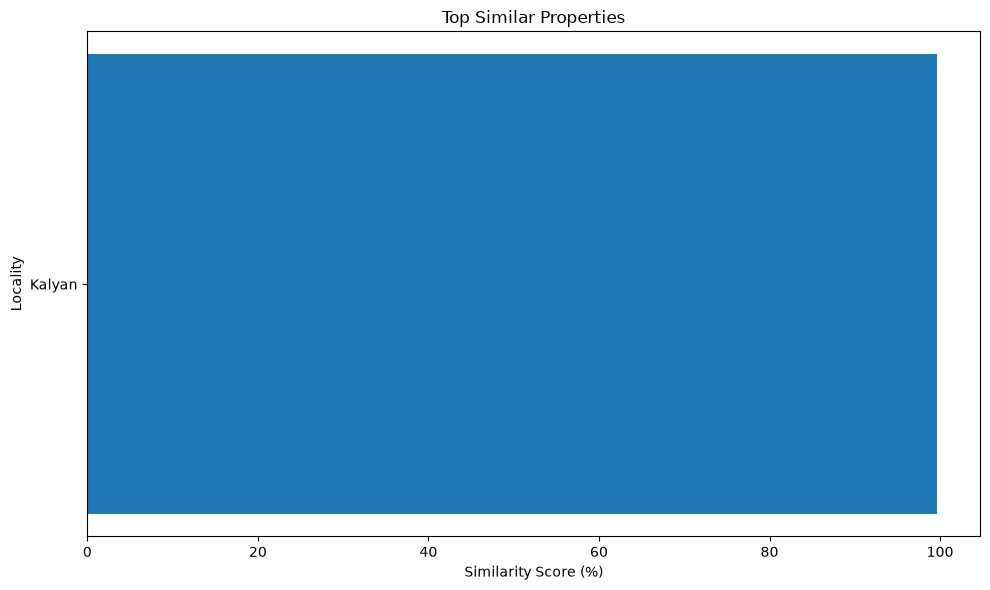

In [22]:
plt.figure(
    figsize=(10, 6)
)

plot_data = (
    similar_properties
    .sort_values(
        "similarity_score",
        ascending=True
    )
)

plt.barh(
    plot_data["locality"].astype(str),
    plot_data["similarity_score"]
)

plt.xlabel(
    "Similarity Score (%)"
)

plt.ylabel(
    "Locality"
)

plt.title(
    "Top Similar Properties"
)

plt.tight_layout()

plt.show()

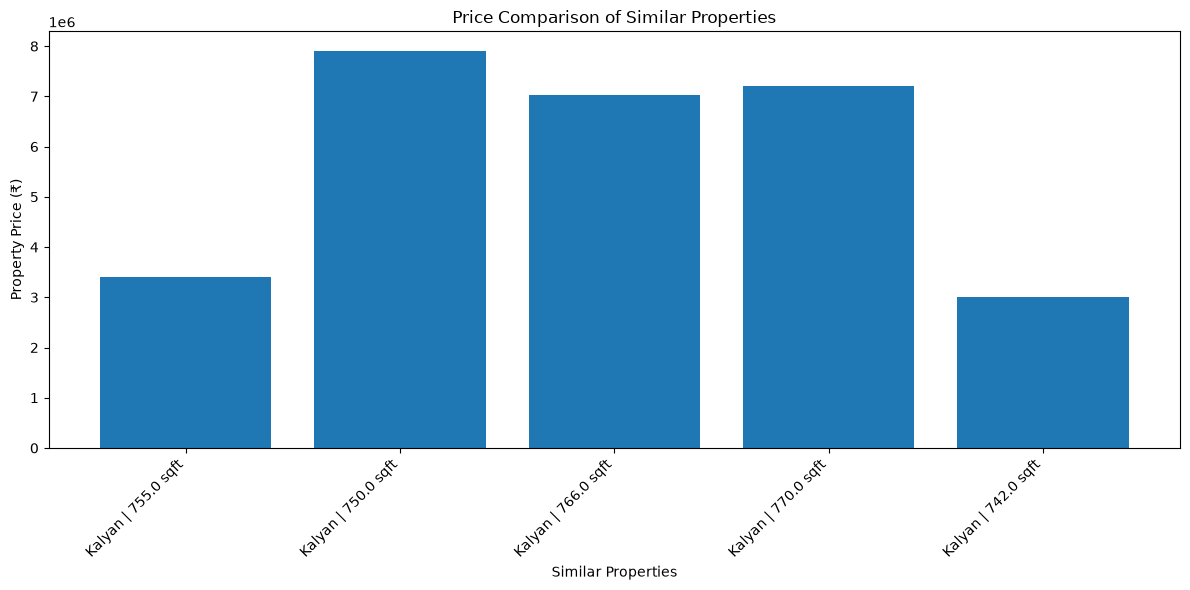

In [23]:
plt.figure(
    figsize=(12, 6)
)

top_prices = similar_properties.copy()

top_prices["property_label"] = (
    top_prices["locality"].astype(str)
    + " | "
    + top_prices["area"].astype(str)
    + " sqft"
)

plt.bar(
    top_prices["property_label"],
    top_prices["price"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel(
    "Property Price (₹)"
)

plt.xlabel(
    "Similar Properties"
)

plt.title(
    "Price Comparison of Similar Properties"
)

plt.tight_layout()

plt.show()

In [24]:
similar_property_result = {
    "target_property": {
        "price": target_price,
        "predicted_price": target_predicted_price,
        "locality": target_property["locality"],
        "area": target_property["area"],
        "bedrooms": target_property["bedroom_num"],
        "bathrooms": target_property["bathroom_num"]
    },

    "similar_property_count": len(
        similar_properties
    ),

    "average_similar_price": (
        float(average_similar_price)
    ),

    "average_similar_predicted_price": (
        float(average_similar_predicted_price)
    ),

    "difference_from_average": (
        float(price_difference)
    ),

    "difference_percent": (
        float(price_difference_percent)
    ),

    "comparison_message": (
        comparison_message
    )
}

similar_property_result

{'target_property': {'price': 6600283.0,
  'predicted_price': 5749573.439304057,
  'locality': 'Kalyan',
  'area': np.int64(757),
  'bedrooms': np.int64(2),
  'bathrooms': np.int64(2)},
 'similar_property_count': 10,
 'average_similar_price': 5597092.2,
 'average_similar_predicted_price': 5614844.946641729,
 'difference_from_average': 152481.2393040564,
 'difference_percent': 2.724293862875019,
 'comparison_message': 'The predicted price is close to the average price of similar properties.'}

In [25]:
similar_properties_path = os.path.join(
    OUTPUT_DIR,
    "similar_properties_sample.csv"
)

similar_properties.to_csv(
    similar_properties_path,
    index=False
)

print(
    "Similar properties saved successfully:"
)

print(
    similar_properties_path
)

Similar properties saved successfully:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\similar_properties_sample.csv


In [26]:
similarity_model_path = os.path.join(
    OUTPUT_DIR,
    "similar_property_model.pkl"
)

similarity_scaler_path = os.path.join(
    OUTPUT_DIR,
    "similar_property_scaler.pkl"
)

categorical_columns_path = os.path.join(
    OUTPUT_DIR,
    "similar_property_categories.pkl"
)

similarity_data_path = os.path.join(
    OUTPUT_DIR,
    "similar_property_data.pkl"
)

joblib.dump(
    similarity_model,
    similarity_model_path
)

joblib.dump(
    scaler,
    similarity_scaler_path
)

joblib.dump(
    categorical_encoded.columns.tolist(),
    categorical_columns_path
)

joblib.dump(
    similarity_df,
    similarity_data_path
)

print("Files saved successfully.")

Files saved successfully.


In [27]:
saved_files = [
    similarity_model_path,
    similarity_scaler_path,
    categorical_columns_path,
    similarity_data_path,
    similar_properties_path
]

for file_path in saved_files:

    exists = os.path.exists(
        file_path
    )

    print(
        f"{os.path.basename(file_path)} :",
        "OK" if exists else "MISSING"
    )

similar_property_model.pkl : OK
similar_property_scaler.pkl : OK
similar_property_categories.pkl : OK
similar_property_data.pkl : OK
similar_properties_sample.csv : OK


In [28]:
def get_similar_properties_for_input(
    area,
    bedroom_num,
    bathroom_num,
    balcony_num,
    age,
    total_floors,
    locality,
    property_type,
    furnished,
    top_n=5
):

    input_numeric = np.array([[
        area,
        bedroom_num,
        bathroom_num,
        balcony_num,
        age,
        total_floors
    ]], dtype=float)

    input_numeric_scaled = scaler.transform(
        input_numeric
    )

    input_categorical = pd.DataFrame(
        [[
            locality,
            property_type,
            furnished
        ]],
        columns=categorical_features
    )

    input_categorical_encoded = (
        pd.get_dummies(
            input_categorical,
            dtype=float
        )
    )

    input_categorical_encoded = (
        input_categorical_encoded.reindex(
            columns=categorical_encoded.columns,
            fill_value=0
        )
    )

    input_features = np.hstack([
        input_numeric_scaled,
        input_categorical_encoded.values
    ])

    distances, indices = (
        similarity_model.kneighbors(
            input_features,
            n_neighbors=top_n
        )
    )

    results = []

    for distance, idx in zip(
        distances[0],
        indices[0]
    ):

        row = similarity_df.iloc[idx]

        similarity_score = (
            1 / (1 + distance)
        ) * 100

        results.append({
            "similarity_score": round(
                similarity_score,
                2
            ),
            "price": float(
                row["price"]
            ),
            "predicted_price": float(
                row["predicted_price"]
            ),
            "area": float(
                row["area"]
            ),
            "locality": str(
                row["locality"]
            ),
            "bedroom_num": int(
                row["bedroom_num"]
            ),
            "bathroom_num": int(
                row["bathroom_num"]
            ),
            "property_type": str(
                row["property_type"]
            ),
            "furnished": str(
                row["furnished"]
            )
        })

    return pd.DataFrame(results)

In [29]:
test_results = get_similar_properties_for_input(

    area=650,

    bedroom_num=1,

    bathroom_num=2,

    balcony_num=0,

    age=5,

    total_floors=10,

    locality="Thane",

    property_type="Apartment",

    furnished="Unfurnished",

    top_n=5
)

display(test_results)

c:\Users\Tejas Dalvi\anaconda3\anaconda\envs\mumbai-house\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,similarity_score,price,predicted_price,area,locality,bedroom_num,bathroom_num,property_type,furnished
0,9.32,4300000.0,4300000.0,531.0,Nalasopara,2,2,Independent Floor,Unfurnished
1,9.00,42120000.0,40953700.0,1170.0,Vile Parle E,3,3,Independent Floor,Semi-Furnished
2,7.29,4300000.0,4300000.0,531.0,Nalasopara,2,2,Independent Floor,Unfurnished
3,7.14,16000000.0,14290500.0,850.0,Thane,2,2,Independent Floor,Semi-Furnished
4,5.98,4300000.0,4300000.0,531.0,Nalasopara,2,2,Independent Floor,Unfurnished


In [30]:
# Conclusion

The Similar Property Finder was successfully developed.

### Features implemented:

- Numerical property similarity
- Locality similarity
- Property type similarity
- Furnishing similarity
- Nearest-neighbor based property matching
- Similarity score
- Top similar properties
- Average similar-property price
- Predicted price comparison
- Price comparison visualization
- Reusable input-based similarity function
- Saved model and preprocessing files

### Files generated:

- `similar_property_model.pkl`
- `similar_property_scaler.pkl`
- `similar_property_categories.pkl`
- `similar_property_data.pkl`
- `similar_properties_sample.csv`

The system is now ready for Flask dashboard integration.

SyntaxError: invalid syntax (3901320676.py, line 3)